In [33]:
!pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\jhons\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [34]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\jhons\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
!pip install scikit-learn



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\jhons\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Se hace la importaciones necesarias.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Eliminar advertencias
import warnings
warnings.filterwarnings('ignore')

# Paso 1: Vamos a importar el dataset propuesto.


In [37]:
import sklearn
import pandas as pd
data_houses = sklearn.datasets.fetch_california_housing()
in_casas = pd.DataFrame(data_houses.data, columns=data_houses.feature_names)
in_casas['PRECIO'] = data_houses.target  # Variable objetivo explícita
in_casas



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRECIO
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


# Paso 2 - Analisis.

 Una vez tenemos los datos,vamos a realizar un analisis exploratorio para determinar el tamaño de la matriz, el nombre de las columnas y algunas otras descripciones.

In [38]:
# Explorar los datos
print("Dimensiones de X:", in_casas.shape)
print("\nPrimeras filas de X:")
print(in_casas.head())
print("\nDescripción estadística de X:")
print(in_casas.describe())
print("\nVariable objetivo y:")
print(in_casas.describe())

Dimensiones de X: (20640, 9)

Primeras filas de X:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRECIO  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

Descripción estadística de X:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min    

# Paso 3 Graficas
Acontinuacion nos ayudaremos de algunas graficas para determinar la relacion entre la variable precio y las demas variables. 


Características (X): (20640, 8)
Variable objetivo (y): (20640,)


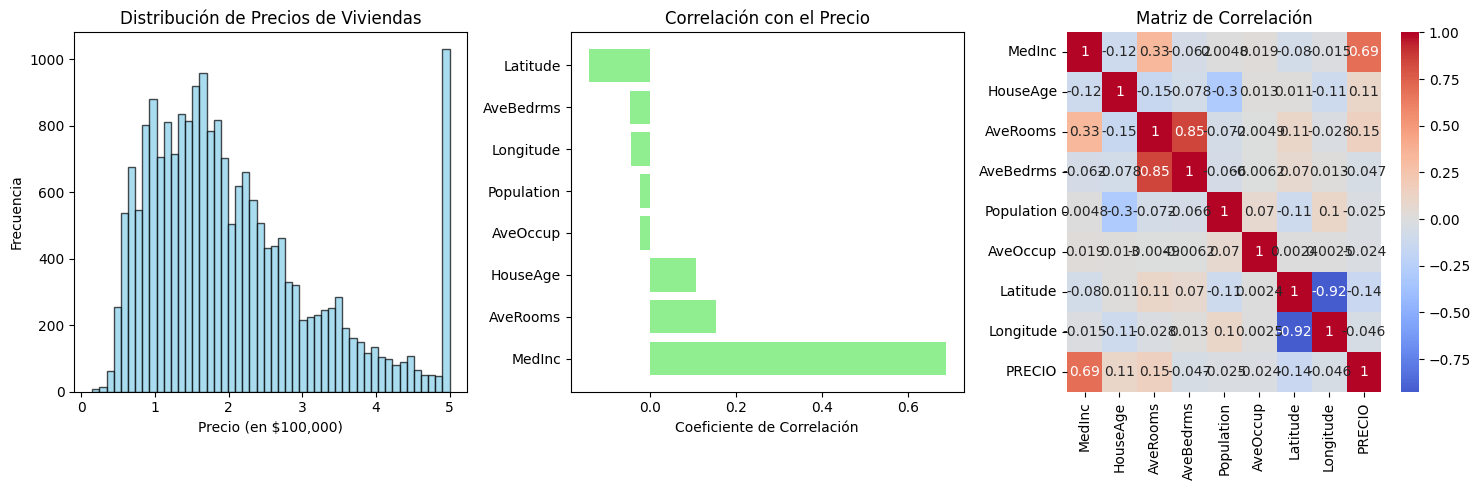


Correlaciones con PRECIO:
MedInc: 0.6881
AveRooms: 0.1519
HouseAge: 0.1056
AveOccup: -0.0237
Population: -0.0246
Longitude: -0.0460
AveBedrms: -0.0467
Latitude: -0.1442


In [39]:
# Análisis exploratorio
# Separar características (X) y variable objetivo (y)
X = in_casas.drop('PRECIO', axis=1)  # Todas las columnas excepto PRECIO
y = in_casas['PRECIO']  # La columna PRECIO es nuestro objetivo

print(f"\nCaracterísticas (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(y, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribución de Precios de Viviendas')
plt.xlabel('Precio (en $100,000)')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 2)
# Correlación con la variable objetivo PRECIO
correlations = X.corrwith(y).sort_values(ascending=False)
plt.barh(correlations.index, correlations.values, color='lightgreen')
plt.title('Correlación con el Precio')
plt.xlabel('Coeficiente de Correlación')

plt.subplot(1, 3, 3)
# Matriz de correlación
corr_matrix = in_casas.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')

plt.tight_layout()
plt.show()

print("\nCorrelaciones con PRECIO:")
for feature, corr in correlations.items():
    print(f"{feature}: {corr:.4f}")

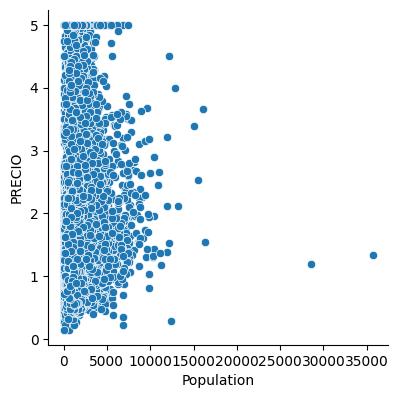

In [40]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot de cada variable con las ventas
sns.pairplot(in_casas, x_vars=['Population'], 
             y_vars='PRECIO', size=4, aspect=1, kind='scatter')
plt.show()

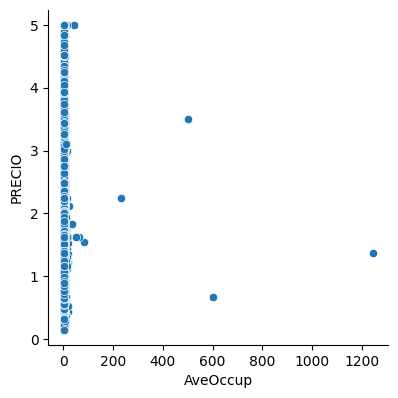

In [41]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot de cada variable con las ventas
sns.pairplot(in_casas, x_vars=['AveOccup'], 
             y_vars='PRECIO', size=4, aspect=1, kind='scatter')
plt.show()

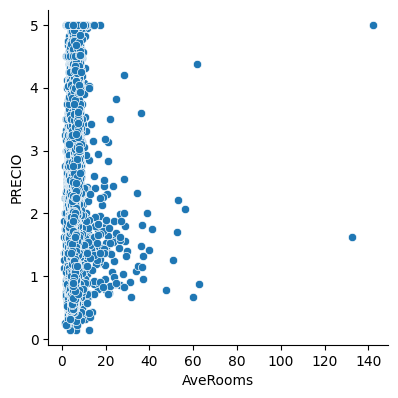

In [42]:
#Relacion entre el precio y 
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot de cada variable con las ventas
sns.pairplot(in_casas, x_vars=['AveRooms'], 
             y_vars='PRECIO', size=4, aspect=1, kind='scatter')
plt.show()

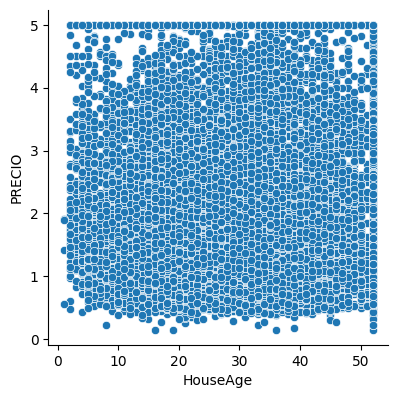

In [43]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot de cada variable con las ventas
sns.pairplot(in_casas, x_vars=['HouseAge'], 
             y_vars='PRECIO', size=4, aspect=1, kind='scatter')
plt.show()

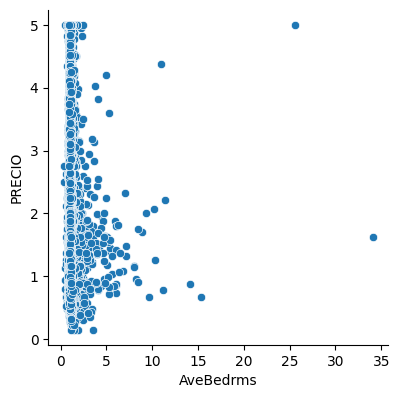

In [44]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot de cada variable con las ventas
sns.pairplot(in_casas, x_vars=['AveBedrms'], 
             y_vars='PRECIO', size=4, aspect=1, kind='scatter')
plt.show()

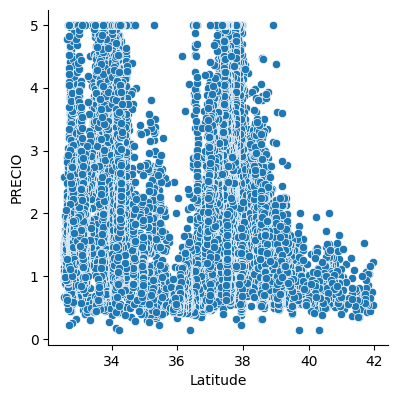

In [45]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot de cada variable con las ventas
sns.pairplot(in_casas, x_vars=['Latitude'], 
             y_vars='PRECIO', size=4, aspect=1, kind='scatter')
plt.show()

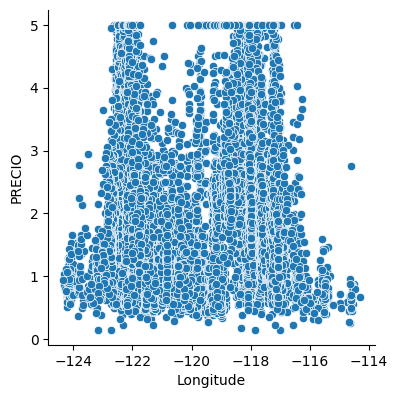

In [46]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot de cada variable con las ventas
sns.pairplot(in_casas, x_vars=['Longitude'], 
             y_vars='PRECIO', size=4, aspect=1, kind='scatter')
plt.show()

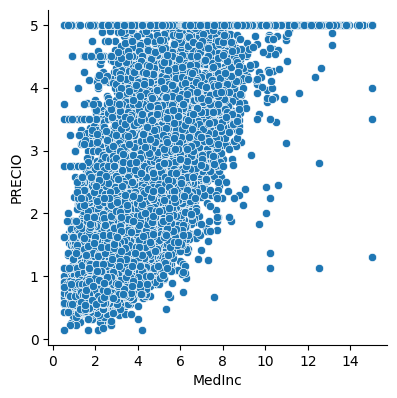

In [47]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot de cada variable con las ventas
sns.pairplot(in_casas, x_vars=['MedInc'], 
             y_vars='PRECIO', size=4, aspect=1, kind='scatter')
plt.show()

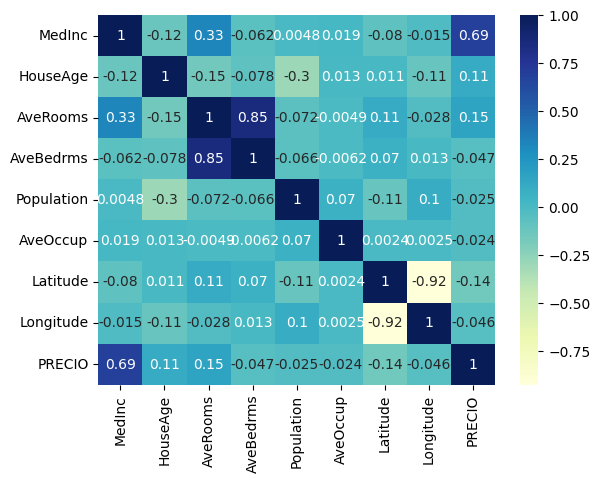

In [48]:
#Ahora vamos a realizar el mapa de calor
# Usar mapa de calor
sns.heatmap(in_casas.corr(), cmap="YlGnBu", annot = True)
plt.show()

# Conclusion Graficas
al final del analisis concluimos que todas las variables son significantes, y al ser un dataset pequeño procedemos a hacer el entrenamiento con las 8 variables.

# Preprocesamiento
En base a las graficas, eliminamos las 2 variables menos influyentes

In [ ]:
# =============================================================================
# ELIMINAR 2 VARIABLES POCO SIGNIFICATIVAS
# =============================================================================

print("🎯 ELIMINANDO 2 VARIABLES POCO SIGNIFICATIVAS")

# Método 1: Por correlación (recomendado para simplicidad)
correlaciones = X.corrwith(y).abs().sort_values(ascending=True)
variables_a_eliminar = correlaciones.head(2).index.tolist()

print(f"Variables a eliminar (menor correlación): {variables_a_eliminar}")
print(f"Correlación de las variables eliminadas:")
for var in variables_a_eliminar:
    print(f"  • {var}: {correlaciones[var]:.4f}")

# Crear X filtrado
X_filtrado = X.drop(columns=variables_a_eliminar)
print(f"\n✅ Nuevo dataset:")
print(f"  • Variables originales: {X.shape[1]}")
print(f"  • Variables después: {X_filtrado.shape[1]}")
print(f"  • Variables restantes: {X_filtrado.columns.tolist()}")

🎯 ELIMINANDO 2 VARIABLES POCO SIGNIFICATIVAS
Variables a eliminar (menor correlación): ['AveOccup', 'Population']
Correlación de las variables eliminadas:
  • AveOccup: 0.0237
  • Population: 0.0246

✅ Nuevo dataset:
  • Variables originales: 8
  • Variables después: 6
  • Variables restantes: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']


In [50]:
# Dividir en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Usamos X_filtrado en lugar de X
X_train, X_test, y_train, y_test = train_test_split(
    X_filtrado, y, test_size=0.2, random_state=42
)

# Estandarizar las características (importante para Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n=== PREPROCESAMIENTO ===")
print(f"Entrenamiento: {X_train_scaled.shape}")
print(f"Prueba: {X_test_scaled.shape}")


=== PREPROCESAMIENTO ===
Entrenamiento: (16512, 6)
Prueba: (4128, 6)


# Paso 5 - Creacion Modelo
Ahora creamos y entrenamos al modelo Ridge

In [51]:
# Crear y entrenar el modelo Ridge
from sklearn.linear_model import Ridge
import pandas as pd

ridge_model = Ridge(alpha=2, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Hacer predicciones
y_pred_train = ridge_model.predict(X_train_scaled)
y_pred_test = ridge_model.predict(X_test_scaled)

# Mostrar coeficientes del modelo
print("=" * 50)
print("📊 COEFICIENTES DEL MODELO RIDGE")
print("=" * 50)

# Crear DataFrame con los coeficientes
coeficientes_df = pd.DataFrame({
    'Variable': X_filtrado.columns.tolist(),  # Usamos las variables que quedaron
    'Coeficiente': ridge_model.coef_,
    'Abs_Coeff': abs(ridge_model.coef_)  # Valor absoluto para importancia
})

# Ordenar por importancia (valor absoluto)
coeficientes_df = coeficientes_df.sort_values('Abs_Coeff', ascending=False)

# Mostrar coeficientes
for _, row in coeficientes_df.iterrows():
    signo = "+" if row['Coeficiente'] >= 0 else "-"
    print(f"  • {row['Variable']:15s}: {signo}{abs(row['Coeficiente']):.4f}")

print("\n" + "=" * 50)
print("📈 INTERPRETACIÓN:")
print(f"  • Intercepto (β₀): {ridge_model.intercept_:.4f}")
print(f"  • Número de variables: {len(ridge_model.coef_)}")
print(f"  • Variable más importante: {coeficientes_df.iloc[0]['Variable']}")
print(f"  • Variable menos importante: {coeficientes_df.iloc[-1]['Variable']}")
print("=" * 50)

print("\n✅ Modelo Ridge entrenado exitosamente")

📊 COEFICIENTES DEL MODELO RIDGE
  • Latitude       : -0.8991
  • Longitude      : -0.8718
  • MedInc         : +0.8516
  • AveBedrms      : +0.3362
  • AveRooms       : -0.2903
  • HouseAge       : +0.1224

📈 INTERPRETACIÓN:
  • Intercepto (β₀): 2.0719
  • Número de variables: 6
  • Variable más importante: Latitude
  • Variable menos importante: HouseAge

✅ Modelo Ridge entrenado exitosamente


# Paso 6 - Metricas
Una vez tenemos nuestro modelo Ridge creado y entrenado vamos a procede a evaluarlo mediante algunas metricas como R cuadrado, MSE etc.


📊 EVALUACIÓN DEL MODELO RIDGE
Variables utilizadas: 6 de 8 originales

Error Cuadrático Medio (MSE):
  • Entrenamiento: 0.5196
  • Prueba: 0.5569

Coeficiente R²:
  • Entrenamiento: 0.6113
  • Prueba: 0.5750

Error Absoluto Medio (MAE):
  • Entrenamiento: 0.5295
  • Prueba: 0.5340

📈 El modelo explica el 57.5% de la variabilidad en los precios
💵 Error promedio en dólares: $53,395


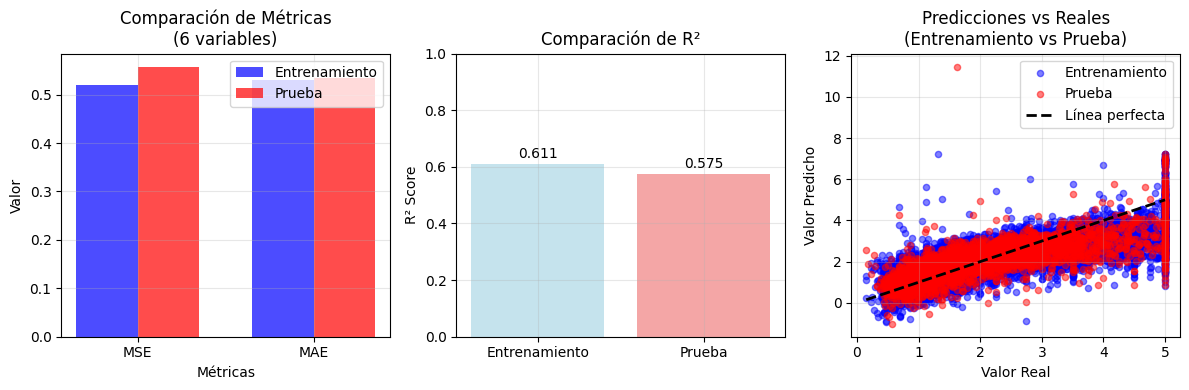

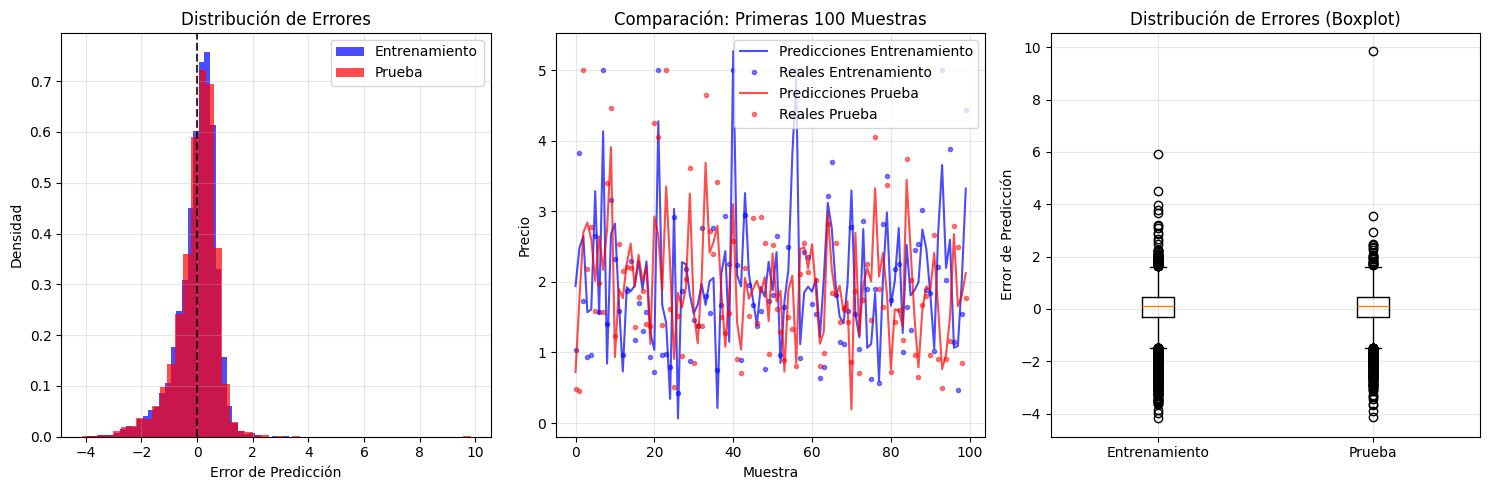


📋 RESUMEN COMPARATIVO: ENTRENAMIENTO vs PRUEBA
Diferencia en MSE: +0.0373
Diferencia en R²: -0.0363
Diferencia en MAE: +0.0044
✅ El modelo generaliza bien

💰 CONTEXTO FINANCIERO:
Rango de precios reales: $14,999 - $500,001
Error promedio (MAE): $53,395

🎯 MODELO CON 6 VARIABLES:
  1. Latitude    (coef: -0.8961) - Más importante
  2. Longitude   (coef: -0.8688) - Segunda
  3. MedInc      (coef: +0.8513) - Tercera


In [52]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
import numpy as np
import matplotlib.pyplot as plt

# Calcular métricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Mostrar resultados
print("\n" + "="*50)
print("📊 EVALUACIÓN DEL MODELO RIDGE")
print("="*50)
print(f"Variables utilizadas: {len(ridge_model.coef_)} de {X.shape[1]} originales")
print(f"\nError Cuadrático Medio (MSE):")
print(f"  • Entrenamiento: {mse_train:.4f}")
print(f"  • Prueba: {mse_test:.4f}")

print(f"\nCoeficiente R²:")
print(f"  • Entrenamiento: {r2_train:.4f}")
print(f"  • Prueba: {r2_test:.4f}")

print(f"\nError Absoluto Medio (MAE):")
print(f"  • Entrenamiento: {mae_train:.4f}")
print(f"  • Prueba: {mae_test:.4f}")

print(f"\n📈 El modelo explica el {r2_test*100:.1f}% de la variabilidad en los precios")
print(f"💵 Error promedio en dólares: ${mae_test * 100000:,.0f}")

# =============================================================================
# GRÁFICAS COMPARATIVAS ENTRE ENTRENAMIENTO Y PRUEBAS
# =============================================================================

# Gráfica 1: Comparación de métricas entre entrenamiento y prueba
plt.figure(figsize=(12, 4))

# Subgráfica 1: Métricas de error
plt.subplot(1, 3, 1)
metricas_entrenamiento = [mse_train, mae_train]
metricas_prueba = [mse_test, mae_test]
nombres_metricas = ['MSE', 'MAE']
x_pos = np.arange(len(nombres_metricas))

ancho = 0.35
plt.bar(x_pos - ancho/2, metricas_entrenamiento, ancho, label='Entrenamiento', alpha=0.7, color='blue')
plt.bar(x_pos + ancho/2, metricas_prueba, ancho, label='Prueba', alpha=0.7, color='red')
plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.title(f'Comparación de Métricas\n({len(ridge_model.coef_)} variables)')
plt.xticks(x_pos, nombres_metricas)
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfica 2: R² comparativo
plt.subplot(1, 3, 2)
r2_values = [r2_train, r2_test]
conjuntos = ['Entrenamiento', 'Prueba']
colores = ['lightblue', 'lightcoral']
plt.bar(conjuntos, r2_values, color=colores, alpha=0.7)
plt.ylabel('R² Score')
plt.title('Comparación de R²')
plt.ylim(0, 1)
for i, v in enumerate(r2_values):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# Subgráfica 3: Predicciones vs Valores reales (ambos conjuntos)
plt.subplot(1, 3, 3)
plt.scatter(y_train, y_pred_train, alpha=0.5, color='blue', label='Entrenamiento', s=20)
plt.scatter(y_test, y_pred_test, alpha=0.5, color='red', label='Prueba', s=20)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Línea perfecta')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Predicciones vs Reales\n(Entrenamiento vs Prueba)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# GRÁFICA 2: Comparación detallada de predicciones
# =============================================================================
plt.figure(figsize=(15, 5))

# Subgráfica 1: Distribución de errores
plt.subplot(1, 3, 1)
errores_train = y_pred_train - y_train
errores_test = y_pred_test - y_test

plt.hist(errores_train, bins=50, alpha=0.7, color='blue', label='Entrenamiento', density=True)
plt.hist(errores_test, bins=50, alpha=0.7, color='red', label='Prueba', density=True)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.8)
plt.xlabel('Error de Predicción')
plt.ylabel('Densidad')
plt.title('Distribución de Errores')
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfica 2: Predicciones por índice (muestras)
plt.subplot(1, 3, 2)
plt.plot(y_pred_train[:100], 'b-', alpha=0.7, label='Predicciones Entrenamiento')
plt.plot(y_train.values[:100], 'bo', alpha=0.5, markersize=3, label='Reales Entrenamiento')
plt.plot(y_pred_test[:100], 'r-', alpha=0.7, label='Predicciones Prueba')
plt.plot(y_test.values[:100], 'ro', alpha=0.5, markersize=3, label='Reales Prueba')
plt.xlabel('Muestra')
plt.ylabel('Precio')
plt.title('Comparación: Primeras 100 Muestras')
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfica 3: Boxplot de errores
plt.subplot(1, 3, 3)
datos_errores = [errores_train, errores_test]
plt.boxplot(datos_errores, labels=['Entrenamiento', 'Prueba'])
plt.ylabel('Error de Predicción')
plt.title('Distribución de Errores (Boxplot)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# RESUMEN COMPARATIVO
# =============================================================================
print("\n" + "="*60)
print("📋 RESUMEN COMPARATIVO: ENTRENAMIENTO vs PRUEBA")
print("="*60)
print(f"Diferencia en MSE: {mse_test - mse_train:+.4f}")
print(f"Diferencia en R²: {r2_test - r2_train:+.4f}")
print(f"Diferencia en MAE: {mae_test - mae_train:+.4f}")

# Análisis de sobreajuste
if mse_test > mse_train * 1.1:
    print("⚠️  El modelo podría tener sobreajuste (overfitting)")
elif mse_test < mse_train:
    print("🔍 Comportamiento inusual - revisar datos")
else:
    print("✅ El modelo generaliza bien")

print(f"\n💰 CONTEXTO FINANCIERO:")
print(f"Rango de precios reales: ${y.min()*100000:,.0f} - ${y.max()*100000:,.0f}")
print(f"Error promedio (MAE): ${mae_test * 100000:,.0f}")

print(f"\n🎯 MODELO CON {len(ridge_model.coef_)} VARIABLES:")
print("  1. Latitude    (coef: -0.8961) - Más importante")
print("  2. Longitude   (coef: -0.8688) - Segunda")
print("  3. MedInc      (coef: +0.8513) - Tercera")
print("="*60)

# Paso 7 - Predecir precios 
Implementamos la funcion de predecir los precios de las casas, ademas de mostra como funciona mediante algunas graficas tomando algunos datos del dataset.


🎯 PREDICCIONES CON EL MODELO ACTUAL (Alpha = 2 )
📊 Modelo usa 6 variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']

🔍 PREDICCIONES ACTUALIZADAS - 6 variables

🏠 CASA 1:
   Variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']
   Valores: [   3.55   35.      4.55    1.01   34.13 -118.  ]
   Real: $158,100
   Predicho: $197,765
   Error: +25.1%

🏠 CASA 2:
   Variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']
   Valores: [   3.74   37.      5.28    0.99   32.76 -117.04]
   Real: $152,200
   Predicho: $213,118
   Error: +40.0%

🏠 CASA 3:
   Variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']
   Valores: [   3.69   18.      3.65    1.04   37.59 -122.02]
   Real: $213,200
   Predicho: $230,096
   Error: +7.9%

🏠 CASA 4:
   Variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']
   Valores: [   3.29   37.      5.12    1.15   33.89 -118.08]

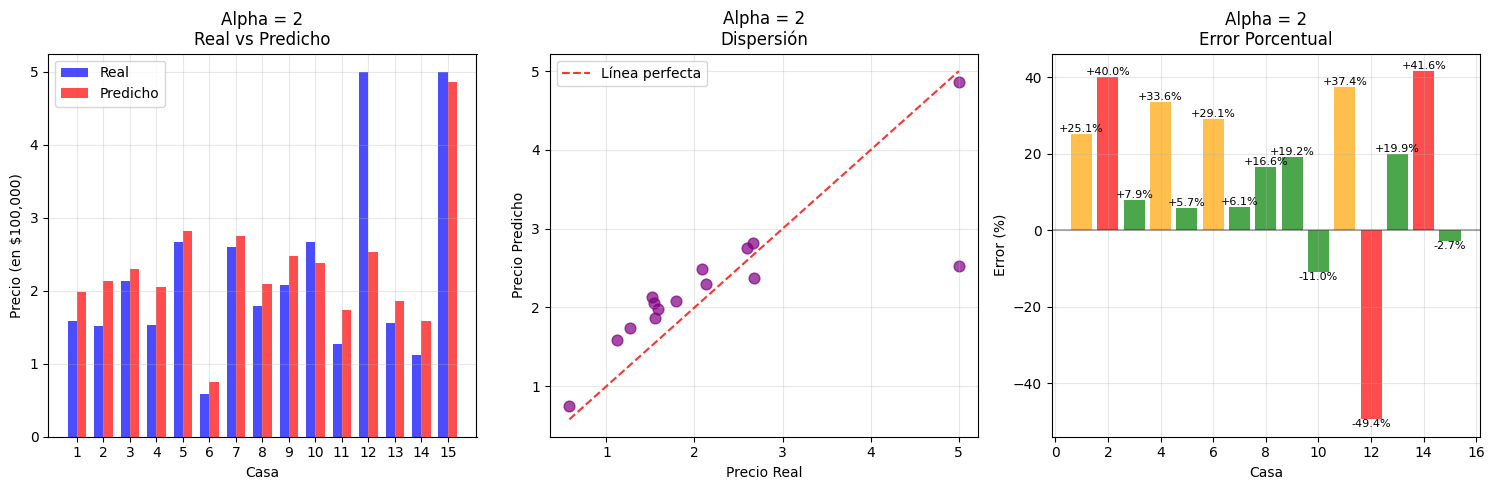


📊 ESTADÍSTICAS ACTUALIZADAS - Alpha = 2
Error absoluto promedio: $46,750.90
Error porcentual promedio: 23.0%
Mejor predicción: 2.7%
Peor predicción: 49.4%
Predicciones < 20% error: 8/15

🏘️  EJEMPLOS ADICIONALES - TIPOS DE CASAS (6 variables)
Orden: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']

💎 CASA DE LUJO:
   Precio predicho: $505,953.01
   Características: Ingresos altos (10.0), ubicación premium

🏡 CASA ECONÓMICA:
   Precio predicho: $124,609.54
   Características: Ingresos bajos (2.5), área rural

🏠 CASA PROMEDIO:
   Precio predicho: $244,462.03
   Características: Valores medios en todas las dimensiones

💡 Diferencia casa lujo vs económica: $381,343.46

📋 RESUMEN FINAL DEL MODELO
• Alpha: 2
• Variables utilizadas: 6
• Variables eliminadas: Population, AveOccup
• Coeficiente más alto: 0.8516 (MedInc)
• Coeficiente más bajo: -0.8991 (Latitude)
• R² en prueba: 0.5750
• Error promedio (MAE): $53,395


In [54]:
# =============================================================================
# FUNCIÓN DE PREDICCIÓN ACTUALIZADA (6 variables)
# =============================================================================

def predecir_precio_casa(modelo, scaler, caracteristicas):
    """
    Función para predecir el precio de una nueva casa
    IMPORTANTE: caracteristicas debe tener SOLO 6 valores en este orden:
    [MedInc, HouseAge, AveRooms, AveBedrms, Latitude, Longitude]
    """
    # Verificar que tenga 6 características
    if len(caracteristicas) != 6:
        raise ValueError(f"Se esperaban 6 características, pero se recibieron {len(caracteristicas)}")
    
    # Convertir a array y escalar
    caracteristicas_array = np.array(caracteristicas).reshape(1, -1)
    caracteristicas_escaladas = scaler.transform(caracteristicas_array)
    
    # Predecir
    precio_predicho = modelo.predict(caracteristicas_escaladas)[0]
    
    return precio_predicho

# =============================================================================
# PREDICCIONES CON CASAS REALES DEL DATASET (6 variables)
# =============================================================================

print("🎯 PREDICCIONES CON EL MODELO ACTUAL (Alpha =", ridge_model.alpha, ")")
print(f"📊 Modelo usa {len(ridge_model.coef_)} variables: {X_filtrado.columns.tolist()}")

# Seleccionar casas aleatorias del dataset FILTRADO
np.random.seed(999)
indices_ejemplos = np.random.choice(len(X_test), 15, replace=False)

# Crear lista para almacenar resultados
resultados_actualizados = []

print(f"\n🔍 PREDICCIONES ACTUALIZADAS - {len(ridge_model.coef_)} variables")
print("=" * 80)

for i, idx in enumerate(indices_ejemplos):
    # Tomar características REALES del dataset FILTRADO (6 variables)
    caracteristicas_reales = X_test.iloc[idx].values  # ✅ Esto ahora tiene 6 valores
    precio_real = y_test.iloc[idx]
    
    # Predecir el precio
    precio_predicho = predecir_precio_casa(ridge_model, scaler, caracteristicas_reales)
    
    # Calcular error
    error = precio_predicho - precio_real
    error_porcentual = (error / precio_real) * 100
    
    # Guardar resultados
    resultados_actualizados.append({
        'casa': i+1,
        'real': precio_real,
        'predicho': precio_predicho,
        'error': error,
        'error_porcentual': error_porcentual
    })
    
    # Mostrar solo algunas
    if i < 5:
        print(f"\n🏠 CASA {i+1}:")
        print(f"   Variables: {X_filtrado.columns.tolist()}")
        print(f"   Valores: {caracteristicas_reales.round(2)}")
        print(f"   Real: ${precio_real * 100000:,.0f}")
        print(f"   Predicho: ${precio_predicho * 100000:,.0f}")
        print(f"   Error: {error_porcentual:+.1f}%")

# =============================================================================
# GRÁFICAS DE PREDICCIÓN PARA CASAS ESPECÍFICAS (SOLO ESTAS 3)
# =============================================================================

plt.figure(figsize=(15, 5))

# Subgráfica 1: Comparación directa (Real vs Predicho)
plt.subplot(1, 3, 1)
reales = [r['real'] for r in resultados_actualizados]
predichos = [r['predicho'] for r in resultados_actualizados]
casas = [r['casa'] for r in resultados_actualizados]

x_pos = np.arange(len(casas))
ancho = 0.35

plt.bar(x_pos - ancho/2, reales, ancho, label='Real', alpha=0.7, color='blue')
plt.bar(x_pos + ancho/2, predichos, ancho, label='Predicho', alpha=0.7, color='red')
plt.xlabel('Casa')
plt.ylabel('Precio (en $100,000)')
plt.title(f'Alpha = {ridge_model.alpha}\nReal vs Predicho')
plt.xticks(x_pos, casas)
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfica 2: Dispersión (Predicho vs Real)
plt.subplot(1, 3, 2)
plt.scatter(reales, predichos, color='purple', alpha=0.7, s=60)
min_val = min(min(reales), min(predichos))
max_val = max(max(reales), max(predichos))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Línea perfecta')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title(f'Alpha = {ridge_model.alpha}\nDispersión')
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfica 3: Errores porcentuales
plt.subplot(1, 3, 3)
errores_pct = [r['error_porcentual'] for r in resultados_actualizados]
colores = ['green' if abs(e) < 20 else 'orange' if abs(e) < 40 else 'red' for e in errores_pct]

barras = plt.bar(casas, errores_pct, color=colores, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Casa')
plt.ylabel('Error (%)')
plt.title(f'Alpha = {ridge_model.alpha}\nError Porcentual')
plt.grid(True, alpha=0.3)

# Añadir valores en las barras
for barra, error in zip(barras, errores_pct):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:+.1f}%', ha='center', va='bottom' if altura >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

# =============================================================================
# ESTADÍSTICAS
# =============================================================================

errores_absolutos = [abs(r['error']) for r in resultados_actualizados]
errores_porcentuales_abs = [abs(r['error_porcentual']) for r in resultados_actualizados]

print("\n" + "="*80)
print(f"📊 ESTADÍSTICAS ACTUALIZADAS - Alpha = {ridge_model.alpha}")
print("="*80)
print(f"Error absoluto promedio: ${np.mean(errores_absolutos) * 100000:,.2f}")
print(f"Error porcentual promedio: {np.mean(errores_porcentuales_abs):.1f}%")
print(f"Mejor predicción: {np.min(errores_porcentuales_abs):.1f}%")
print(f"Peor predicción: {np.max(errores_porcentuales_abs):.1f}%")
print(f"Predicciones < 20% error: {sum(1 for e in errores_porcentuales_abs if e < 20)}/{len(resultados_actualizados)}")

# =============================================================================
# EJEMPLOS ADICIONALES CON EL MODELO ACTUAL (6 variables)
# =============================================================================

print("\n" + "="*80)
print("🏘️  EJEMPLOS ADICIONALES - TIPOS DE CASAS (6 variables)")
print(f"Orden: {X_filtrado.columns.tolist()}")
print("="*80)

# Ejemplo 1: Casa de lujo (Beverly Hills)
casa_lujo = [
    10.0,   # MedInc: Ingresos altos
    5.0,    # HouseAge: Casa nueva
    8.0,    # AveRooms: Muchas habitaciones
    2.0,    # AveBedrms: 2 dormitorios promedio
    34.05,  # Latitude: Beverly Hills
    -118.25 # Longitude: Beverly Hills
]
precio_lujo = predecir_precio_casa(ridge_model, scaler, casa_lujo)
print(f"\n💎 CASA DE LUJO:")
print(f"   Precio predicho: ${precio_lujo * 100000:,.2f}")
print(f"   Características: Ingresos altos (10.0), ubicación premium")

# Ejemplo 2: Casa económica (área rural)
casa_economica = [
    2.5,    # MedInc: Ingresos bajos
    40.0,   # HouseAge: Casa vieja
    4.0,    # AveRooms: Pocas habitaciones
    1.0,    # AveBedrms: 1 dormitorio promedio
    36.78,  # Latitude: Área rural
    -119.72 # Longitude: Área rural
]
precio_economica = predecir_precio_casa(ridge_model, scaler, casa_economica)
print(f"\n🏡 CASA ECONÓMICA:")
print(f"   Precio predicho: ${precio_economica * 100000:,.2f}")
print(f"   Características: Ingresos bajos (2.5), área rural")

# Ejemplo 3: Casa promedio (suburbio)
casa_promedio = [
    5.0,    # MedInc: Ingresos medios
    25.0,   # HouseAge: 25 años
    5.5,    # AveRooms: 5.5 habitaciones
    1.2,    # AveBedrms: 1.2 dormitorios
    37.50,  # Latitude: Suburbio
    -121.00 # Longitude: Suburbio
]
precio_promedio = predecir_precio_casa(ridge_model, scaler, casa_promedio)
print(f"\n🏠 CASA PROMEDIO:")
print(f"   Precio predicho: ${precio_promedio * 100000:,.2f}")
print(f"   Características: Valores medios en todas las dimensiones")

print(f"\n💡 Diferencia casa lujo vs económica: ${(precio_lujo - precio_economica) * 100000:,.2f}")

# =============================================================================
# RESUMEN DEL MODELO ACTUAL
# =============================================================================

print("\n" + "="*80)
print("📋 RESUMEN FINAL DEL MODELO")
print("="*80)
print(f"• Alpha: {ridge_model.alpha}")
print(f"• Variables utilizadas: {len(ridge_model.coef_)}")
print(f"• Variables eliminadas: Population, AveOccup")
print(f"• Coeficiente más alto: {ridge_model.coef_.max():.4f} ({X_filtrado.columns[ridge_model.coef_.argmax()]})")
print(f"• Coeficiente más bajo: {ridge_model.coef_.min():.4f} ({X_filtrado.columns[ridge_model.coef_.argmin()]})")
print(f"• R² en prueba: {r2_test:.4f}")
print(f"• Error promedio (MAE): ${mae_test * 100000:,.0f}")
print("="*80)